### 1. Uraikan secara rinci masalah apa yang dihadapi Bank Sentral berdasarkan informasi awal di atas. Mengapa harus dilakukan predictive analytic dalam masalah ini? Bagaimanakah project ini akan berkontribusi pada pemecahan masalah pada institusi ini?

Answer: Bank Sentral harus memastikan seluruh bank tetap sehat agar sistem kuenagan stabil. Jika salah satu gagal, maka akan terjadi efek domino. Indikator kesehatan bank mencakup rasio keuangan, profitabilitas, likuiditas, leverage, dll. Sulit bagi manusia untuk mendeteksi pola kebangkrutan secara dini hanya dengan analisis tradisional maka diperlukan predictive analysis. Model prediksi ini bisa identifikasi bank yang berisiko bangrkut sebelum benar-benart terjadi melalui analysis data serta training yang sesuai sehingga cocok menjadi early warning system agar bank dapat menyesuaikan kebijakan.

In [20]:
# 1) Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, precision_recall_curve, auc
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)

In [21]:
# 2) Load data
# Replace with your file path (e.g., '/content/bankruptcy.csv')
csv_path = 'data-bank.csv'
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.dtypes.head(10))
df.head(3)

Shape: (6819, 96)
Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
 Realized Sales Gross Margin                                float64
 Operating Profit Rate                                      float64
 Pre-tax net Interest Rate                                  float64
 After-tax net Interest Rate                                float64
 Non-industry income and expenditure/revenue                float64
dtype: object


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,0.000126,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,0.000290,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.006889,0.391

### 2. Data Understanding, jabarkan apa yang menjadi target variable? Buatkan visualisasi tahapan Exploratory Data Analysis untuk melihat beberapa hubungan 2 variable dengan target variable.

Answer: Target variable berupa `Bankrupt?` berupa tipe column dengan data tipe `int64` diantara `0` (masih operasional) atau `1` (sudah bangkrut). Karena tujuan nya adalah prediksi kemungkinan bangkrut, makan `Bankrupt?` cocok dijadikan sebagai target variable. Untuk hubungan variabel-variabel terhadap target variabel terdapat pada heatmap.


### 3. Data Preparation, Apakah data ini “Balance”? dan jika tidak, bagaimana cara untuk menangani data yang tidak balance? Buatkan juga tahapan data cleaning dan data transformation nya. 

Answer: Tidak balance. Dengan menjalankan `print("Target distribution:")` dan `print(df[TARGET_COL].value_counts(), '\n')` didapatkan output sebagai berikut:

```
Numeric features: 95
Target distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64 

Target proportion:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64
```

Dari sini, dapat disimpulkan bahwa distribusi data tidak balance dengan `6599` bank sehat dan `220` bank bangkrut. Berarti dalam pelatihan modelnya, akan terjadi bias terhadap kelas mayoritas. Kode dibawah menunjukan teknik yang dilakukan jika kita tetap melakukan pelatihan tanpa memastikan distribusi data yang seimbang salah satu nya dengan teknik SMOTE (menambah data sintesis untuk kelas minoritas). Namun, solusi yang paling tepat adalah tetap membagi data secara proporsional agar model dilatih seimbang.

In [22]:
# 3) Target and feature setup (numeric-only)
TARGET_COL = 'Bankrupt?'
assert TARGET_COL in df.columns, f"Target '{TARGET_COL}' not found. Got: {df.columns.tolist()}"

# Identify numeric features (exclude target)
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove(TARGET_COL)

print("Numeric features:", len(numeric_features))
print("Target distribution:")
print(df[TARGET_COL].value_counts(), '\n')
print("Target proportion:")
print(df[TARGET_COL].value_counts(normalize=True))

Numeric features: 95
Target distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64 

Target proportion:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


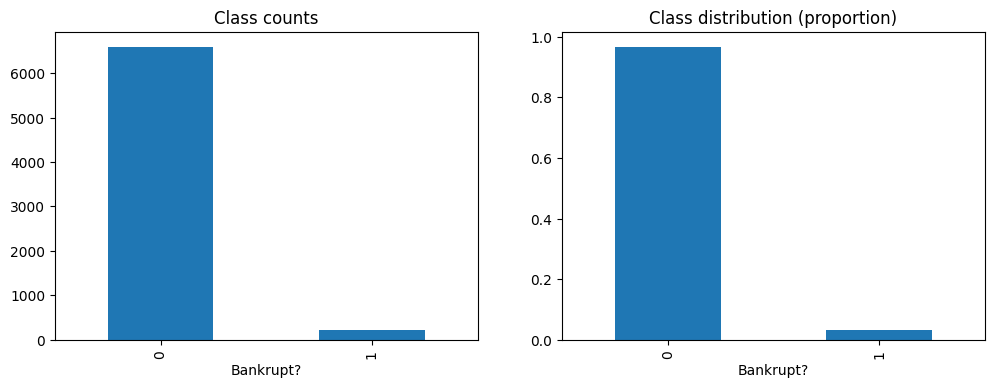

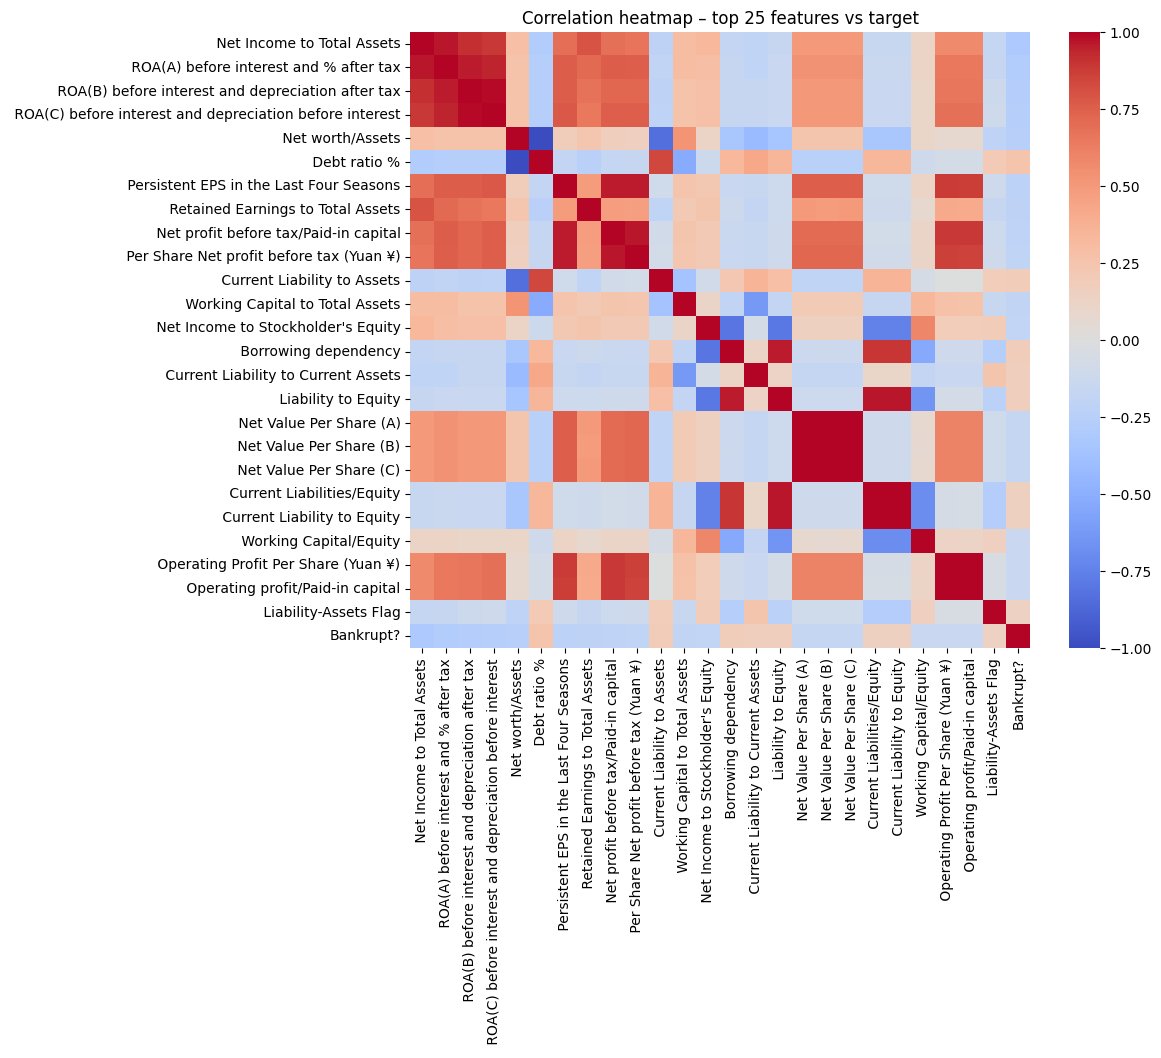

Top 10 features by |correlation| with target:


Net Income to Total Assets                                 0.315457
ROA(A) before interest and % after tax                     0.282941
ROA(B) before interest and depreciation after tax          0.273051
ROA(C) before interest and depreciation before interest    0.260807
Net worth/Assets                                           0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                    0.219560
Retained Earnings to Total Assets                          0.217779
Net profit before tax/Paid-in capital                      0.207857
Per Share Net profit before tax (Yuan ¥)                   0.201395
Name: Bankrupt?, dtype: float64

In [23]:
# 4) Exploratory data analysis (quick)
# Class balance
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].value_counts().plot(kind='bar', ax=ax[0], title='Class counts')
df[TARGET_COL].value_counts(normalize=True).plot(kind='bar', ax=ax[1], title='Class distribution (proportion)')
plt.show()

# Correlation heatmap (top 25 by abs corr to target for readability)
corr = df[numeric_features + [TARGET_COL]].corr()
abs_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
top_feats = abs_corr.head(25).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feats + [TARGET_COL]].corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap – top 25 features vs target')
plt.show()

print("Top 10 features by |correlation| with target:")
display(abs_corr.head(10))


In [24]:
# 5) Split
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

In [25]:
# 6) Preprocessing (numeric-only): impute median + scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='drop'  # drop any non-numeric if present
)

In [26]:
# 7) Check class imbalance and decide SMOTE
minority_ratio = y_train.value_counts(normalize=True).min()
use_smote = minority_ratio < 0.35  # heuristic
print(f"Minority ratio: {minority_ratio:.3f} | Use SMOTE: {use_smote}")

Minority ratio: 0.032 | Use SMOTE: True


### 4. Modelling, Gunakan algoritma seperti Random Forest, Decision Tree, Artificial Neural Network. Manakah algoritma yang paling sesuai dengan dataset yang ada saat ini? 

Answer: Kode dibawah menunjukan tiga algoritma yang kemudian dilatih lalu dibandingkan hasil akurasi awal nya. Jika run bagian `10) Cross-validation (F1 Focus)` didapatkan output sebagai berikut:

```
DecisionTree | F1: 0.800 ± 0.039 | ROC AUC: 0.791 ± 0.032
RandomForest | F1: 0.860 ± 0.038 | ROC AUC: 0.922 ± 0.039
ANN | F1: 0.845 ± 0.037 | ROC AUC: 0.884 ± 0.035
```

Dapat disimpulkan bahwa RandomForest merupakan algoritma yang paling sesuai dengan dataset sekarang. Hasil evaluasi menunjukkan bahwa Random Forest memiliki performa paling tinggi dibandingkan dengan Decision Tree maupun Artificial Neural Network (ANN). Hal ini dapat dijelaskan sebagai berikut:

<b>A. Decision Tree:</b>
- Mudah diinterpretasi, namun cenderung overfitting pada dataset yang kompleks.
- Nilai F1 dan ROC AUC lebih rendah karena model tunggal kurang mampu menangkap variasi data.

<b>B. Random Forest:</b>
- Merupakan ensemble dari banyak Decision Tree sehingga lebih stabil dan akurat.
- Mampu menangani data yang tidak seimbang dengan baik melalui mekanisme class weight.
- Memberikan hasil terbaik (F1: 0.860, ROC AUC: 0.922) sehingga paling sesuai untuk kasus prediksi kebangkrutan.

<b>C. Artificial Neural Network (ANN):</b>

- Dapat menangkap pola non-linear, namun membutuhkan tuning lebih lanjut dan data yang lebih besar agar optimal.
- Performanya cukup baik (F1: 0.845, ROC AUC: 0.884), tetapi masih di bawah Random Forest.

In [40]:
# 8) Define models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Decision Tree (baseline, interpretable)
dt = DecisionTreeClassifier(
    max_depth=None, min_samples_split=4,
    random_state=RANDOM_STATE, class_weight='balanced'
)

# Random Forest (ensemble of trees, robust)
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_split=4,
    random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced_subsample'
)

# Artificial Neural Network (MLPClassifier in scikit-learn)
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu',
    solver='adam', max_iter=500, random_state=RANDOM_STATE
)


In [41]:
# 9) Build pipelines (with/without SMOTE)
def build_pipeline(clf, use_smote=False):
    if use_smote:
        return ImbPipeline(steps=[
            ('preprocess', preprocess),
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('clf', clf)
        ])
    else:
        return Pipeline(steps=[('preprocess', preprocess), ('clf', clf)])

pipelines = {
    'DecisionTree': build_pipeline(dt, use_smote),
    'RandomForest': build_pipeline(rf, use_smote),
    'ANN': build_pipeline(ann, use_smote)
}


In [42]:
# 10) Cross-validation (F1 focus)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(name, pipe, X, y):
    scores_f1 = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
    scores_auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(f"{name} | F1: {scores_f1.mean():.3f} ± {scores_f1.std():.3f} | ROC AUC: {scores_auc.mean():.3f} ± {scores_auc.std():.3f}")

for name, pipe in pipelines.items():
    evaluate_cv(name, pipe, X_train, y_train)


DecisionTree | F1: 0.800 ± 0.039 | ROC AUC: 0.791 ± 0.032
RandomForest | F1: 0.860 ± 0.038 | ROC AUC: 0.922 ± 0.039
ANN | F1: 0.845 ± 0.037 | ROC AUC: 0.884 ± 0.035


### 5. Evaluation, Lakukan evaluasi dari model yang anda sudah buat. Sajikan Confusion Matrix, Precision, Recall, f1-score dan sebagainya. 

Answer:

Model: RandomForest
              precision    recall  f1-score   support

           0     0.8958    0.8431    0.8687        51
           1     0.8000    0.8649    0.8312        37

    accuracy                         0.8523        88
   macro avg     0.8479    0.8540    0.8499        88
weighted avg     0.8555    0.8523    0.8529        88



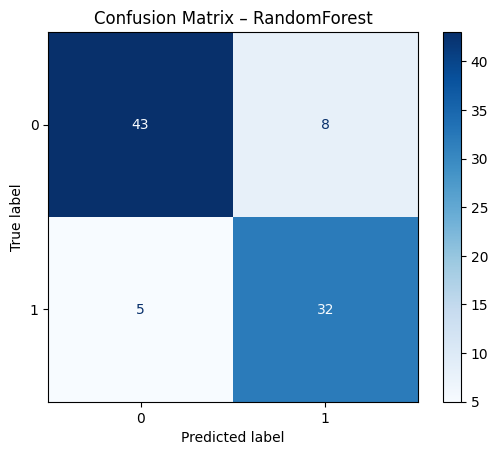

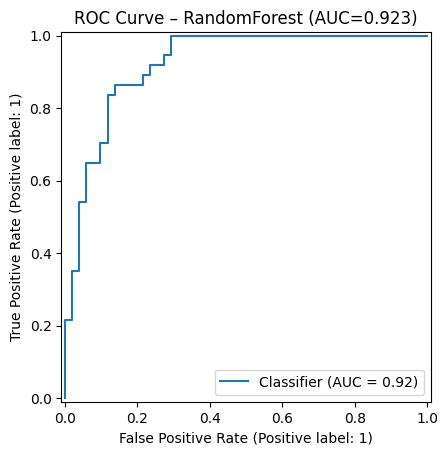

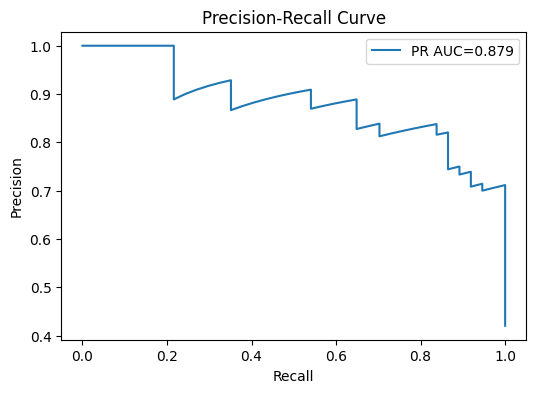

In [43]:
# 11) Fit best model (set based on CV results)
best_model_name = 'RandomForest'
best_pipe = pipelines[best_model_name]
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
try:
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
except Exception:
    y_proba = None

print(f"Model: {best_model_name}")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix – {best_model_name}')
plt.show()

if y_proba is not None:
    roc_auc = roc_auc_score(y_test, y_proba)
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f'ROC Curve – {best_model_name} (AUC={roc_auc:.3f})')
    plt.show()

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=f'PR AUC={pr_auc:.3f}')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()


### 6. Sebutkan 5 variable yang paling mempengaruhi kebangkrutan sebuah bank.

Answer:

In [ ]:
# 12) Feature importance (top 5)

# Fit preprocessor alone to extract transformer behavior (optional)
_ = preprocess.fit(X_train)

def get_feature_names(preprocessor, numeric_features):
    # After SimpleImputer, StandardScaler, names remain aligned with original numeric_features
    # If you need the imputer names:
    imputer = preprocessor.named_transformers_['num'].named_steps['imputer']
    return imputer.get_feature_names_out(numeric_features)

feature_names = get_feature_names(preprocess, numeric_features)

def top_importances(model_name, pipe, feature_names, k=10):
    clf = pipe.named_steps['clf']
    if model_name in ['RandomForest', 'XGBoost']:
        importances = clf.feature_importances_
    elif model_name == 'LogisticRegression':
        importances = np.abs(clf.coef_[0])
    else:
        raise ValueError("Unsupported model")
    idx = np.argsort(importances)[::-1][:k]
    return pd.DataFrame({'feature': feature_names[idx], 'importance': importances[idx]})

top5 = top_importances(best_model_name, best_pipe, feature_names, k=5)
print("Top 5 features by model importance:")
display(top5)


Top 5 features by model importance:


,feature,importance
0,Borrowing dependency,0.211123
1,Continuous interest rate (after tax),0.067593
2,Persistent EPS in the Last Four Seasons,0.064929
3,Net worth/Assets,0.044659
4,Total debt/Total net worth,0.036614


In [32]:
# Assume best_pipe has already been fit on (X_train, y_train)

# 1. Pick some sample rows from your test set
sample_data = X_test.head(5)

# 2. Predict class labels (0 = healthy, 1 = bankrupt)
pred_labels = best_pipe.predict(sample_data)

# 3. Predict probabilities (likelihood of bankruptcy)
pred_probs = best_pipe.predict_proba(sample_data)[:, 1]

# 4. Combine into a results DataFrame
results = sample_data.copy()
results['Predicted_Label'] = pred_labels
results['Bankruptcy_Probability'] = pred_probs

print(results[['Predicted_Label', 'Bankruptcy_Probability']])


      Predicted_Label  Bankruptcy_Probability
1244                0                0.000224
6303                0                0.000947
4712                0                0.000013
3273                0                0.000022
6430                0                0.000334


### Catatan: Dilakukan training ulang dengan dataset yang lebih "balanced". Tetap didapat bahwa RandomForest lebih sesuai dengan dataset sekarang.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_balanced, y_balanced = rus.fit_resample(X, y)

print(y_balanced.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=RANDOM_STATE
)

# Retry cross-validation with balanced data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(name, pipe, X, y):
    scores_f1 = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
    scores_auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(f"{name} | F1: {scores_f1.mean():.3f} ± {scores_f1.std():.3f} | ROC AUC: {scores_auc.mean():.3f} ± {scores_auc.std():.3f}")

for name, pipe in pipelines.items():
    evaluate_cv(name, pipe, X_train, y_train)


from sklearn.metrics import classification_report, accuracy_score

# Fit best model
best_model_name = 'RandomForest'
best_pipe = pipelines[best_model_name]
best_pipe.fit(X_train, y_train)

# Predictions
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# Core metrics
print(f"Model: {best_model_name}")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Bankrupt?
0    220
1    220
Name: count, dtype: int64
DecisionTree | F1: 0.800 ± 0.039 | ROC AUC: 0.791 ± 0.032
RandomForest | F1: 0.860 ± 0.038 | ROC AUC: 0.922 ± 0.039
ANN | F1: 0.845 ± 0.037 | ROC AUC: 0.884 ± 0.035
Model: RandomForest
Accuracy: 0.8522727272727273
              precision    recall  f1-score   support

           0     0.8958    0.8431    0.8687        51
           1     0.8000    0.8649    0.8312        37

    accuracy                         0.8523        88
   macro avg     0.8479    0.8540    0.8499        88
weighted avg     0.8555    0.8523    0.8529        88



In [36]:
# Assume best_pipe has already been fit on (X_train, y_train)

# 1. Pick some sample rows from your test set
sample_data = X_test.head(5)

# 2. Predict class labels (0 = healthy, 1 = bankrupt)
pred_labels = best_pipe.predict(sample_data)

# 3. Predict probabilities (likelihood of bankruptcy)
pred_probs = best_pipe.predict_proba(sample_data)[:, 1]

# 4. Combine into a results DataFrame
results = sample_data.copy()
results['Predicted_Label'] = pred_labels
results['Bankruptcy_Probability'] = pred_probs

print(results[['Predicted_Label', 'Bankruptcy_Probability']])


      Predicted_Label  Bankruptcy_Probability
1118                1                0.564754
6569                0                0.000743
2095                0                0.126298
645                 1                0.717488
1954                0                0.111470
